In [1]:
import pygmt
import numpy  as np
import xarray as xr

In [139]:
topo = xr.load_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p25/topog_renamed.nc')
grid = xr.load_dataset('/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p25/linked_files/grid.nc')

In [140]:
topo['Bathymetry'] = topo.Bathymetry*(-1)
print(topo.Bathymetry.min().data)
print(topo.Bathymetry.max().data)

-5363.46923828125
-11.805749893188477


In [18]:
def get_indices_within_polygon(dataset, min_lon, max_lon, min_lat, max_lat):
    # Convert 'tlat' and 'tlon' from radians to degrees
    tlat_deg = np.degrees(dataset['tlat'].values)
    tlon_deg = np.degrees(dataset['tlon'].values)
    
    # Create masks for the desired latitude and longitude ranges
    lat_mask = (tlat_deg >= min_lat) & (tlat_deg <= max_lat)
    lon_mask = (tlon_deg >= min_lon) & (tlon_deg <= max_lon)
    
    # Combine the latitude and longitude masks
    region_mask = lat_mask & lon_mask
    
    # Get the ny, nx indices where the mask is True
    ny_indices, nx_indices = np.where(region_mask)
    
    return ny_indices, nx_indices


In [ ]:
# MAWSON COAST
min_lon  = 62 
max_lon  = 70 
min_lat  = -67.1 
max_lat  = -66.4  
nyi,nxi  = get_indices_within_polygon(grid, min_lon, max_lon, min_lat, max_lat)
uniq_nyi = np.unique(nyi)
uniq_nxi = np.unique(nxi)
cond     = (topo.Bathymetry.isel(ny=uniq_nyi, nx=uniq_nxi) > -410) & (topo.Bathymetry.isel(ny=uniq_nyi, nx=uniq_nxi) < -390)
topo.Bathymetry.loc[dict(ny=uniq_nyi, nx=uniq_nxi)] = xr.where(cond, 10, topo.Bathymetry.isel(ny=uniq_nyi, nx=uniq_nxi))
# PRINCE OLAV COAST
min_lon  = 38 
max_lon  = 48 
min_lat  = -69 
max_lat  = -66  
nyi,nxi  = get_indices_within_polygon(grid, min_lon, max_lon, min_lat, max_lat)
uniq_nyi = np.unique(nyi)
uniq_nxi = np.unique(nxi)
cond     = (topo.Bathymetry.isel(ny=uniq_nyi, nx=uniq_nxi) > -410) & (topo.Bathymetry.isel(ny=uniq_nyi, nx=uniq_nxi) < -390)
topo.Bathymetry.loc[dict(ny=uniq_nyi, nx=uniq_nxi)] = xr.where(cond, 10, topo.Bathymetry.isel(ny=uniq_nyi, nx=uniq_nxi))

Nearest lat/lon found at indices y=135, x=1369
Bathy depth before modification -289.8253173828125 at lon/lat 62.375/-66.82119129117302
Nearest lat/lon found at indices y=135, x=1369
Bathy depth before modification -0.20000000298023224 at lon/lat 62.375/-66.82119129117302
Nearest lat/lon found at indices y=135, x=1371
Bathy depth before modification -136.97691345214844 at lon/lat 62.87499999999999/-66.82119129117302
Nearest lat/lon found at indices y=134, x=1372
Bathy depth before modification -150.35394287109375 at lon/lat 63.12500000000001/-66.92678988037794
Nearest lat/lon found at indices y=133, x=1373
Bathy depth before modification -126.63887786865234 at lon/lat 63.375/-67.03238846958286
Nearest lat/lon found at indices y=131, x=1376
Bathy depth before modification -122.35127258300781 at lon/lat 64.125/-67.24358564799269
Nearest lat/lon found at indices y=133, x=1379
Bathy depth before modification -205.72776794433594 at lon/lat 64.875/-67.03238846958286
Nearest lat/lon found at i

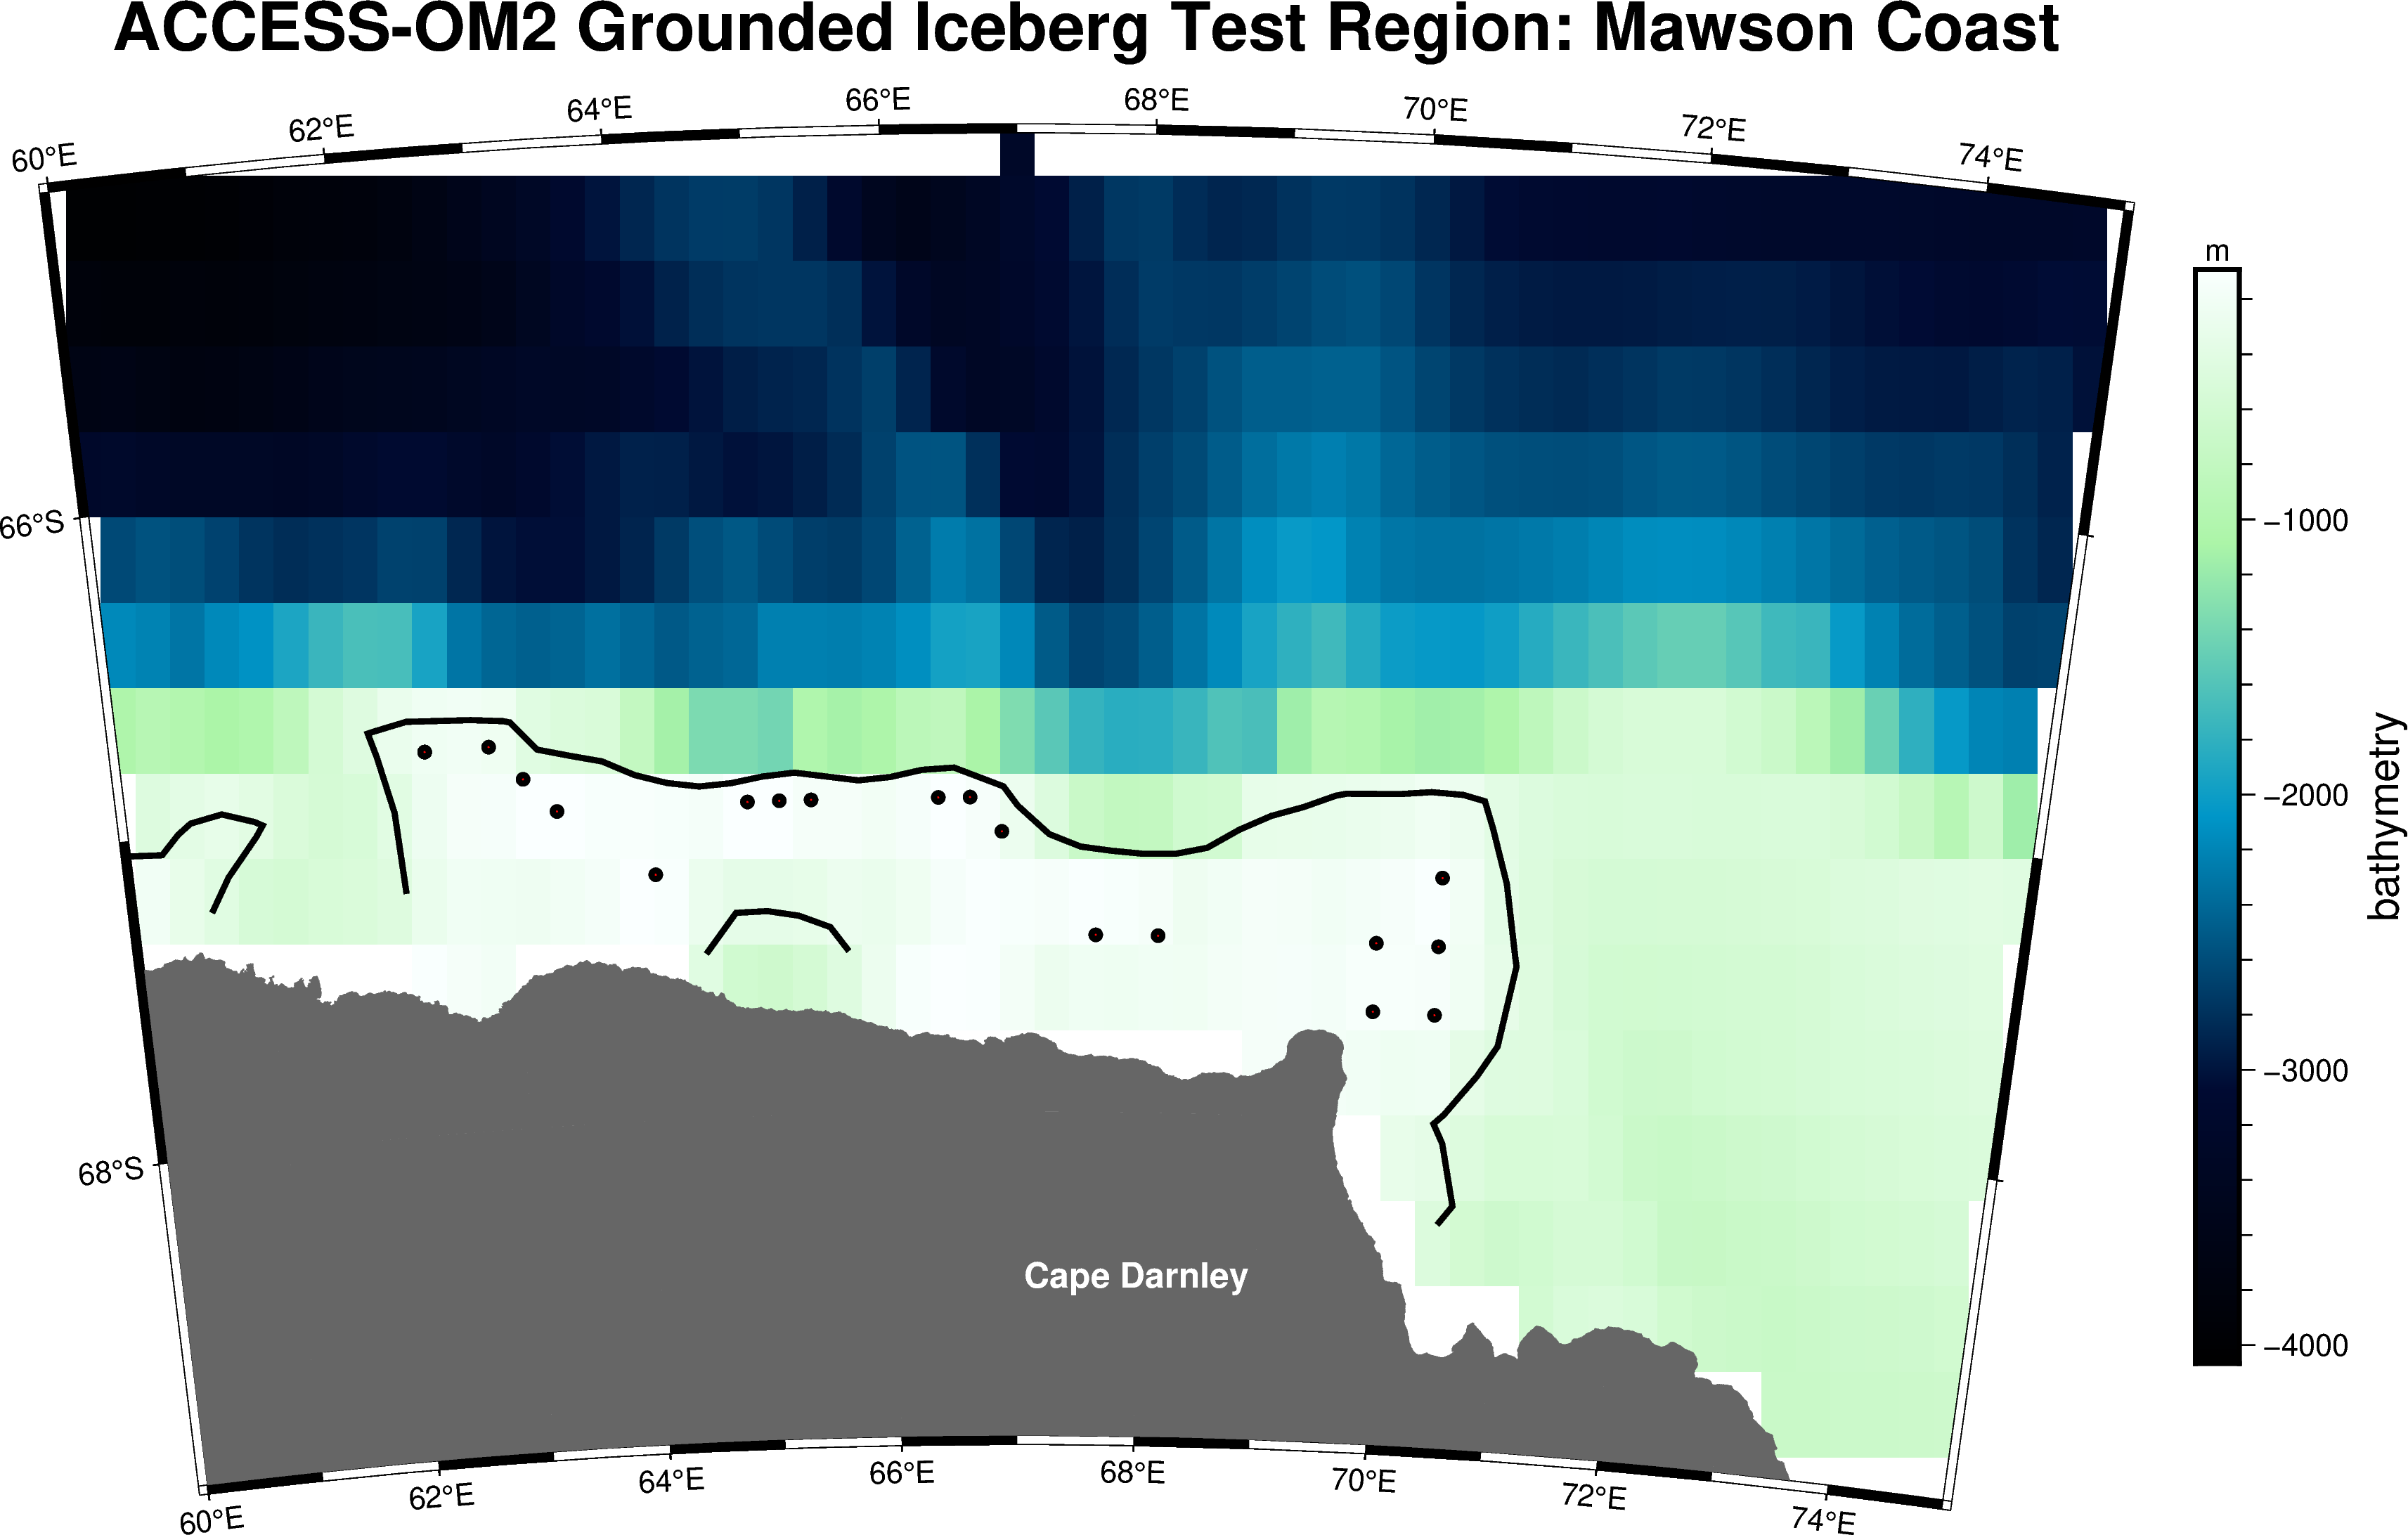

In [141]:
# MAWSON COAST
tlon_deg = np.degrees(grid['tlon'].values)
tlat_deg = np.degrees(grid['tlat'].values)
lon_srch = [ 62.3, 62.5, 62.9, 63.1, 63.5, 64.0, 65.0, 65.2, 65.5, 66.5, 66.7, 67.0, 67.7, 68.1, 70.0, 70.0, 70.3, 70.3, 70.3]
lat_srch = [-66.8,-66.8,-66.8,-66.9,-67.0,-67.2,-67.0,-67.0,-67.0,-67.0,-67.0,-67.1,-67.5,-67.5,-67.5,-67.7,-67.2,-67.5,-67.7]
lon_fnd  = []
lat_fnd  = []
for i in range(len(lon_srch)):   
    lat_diff = (tlat_deg - lat_srch[i])**2
    lon_diff = (tlon_deg - lon_srch[i])**2
    total_diff = lat_diff + lon_diff
    yi, xi = np.unravel_index(total_diff.argmin(), total_diff.shape)
    print(f"Nearest lat/lon found at indices y={yi}, x={xi}")
    print(f'Bathy depth before modification {topo.Bathymetry[yi,xi].data} at lon/lat {tlon_deg[yi,xi]}/{tlat_deg[yi,xi]}')
    lon_fnd.append(tlon_deg[yi,xi])
    lat_fnd.append(tlat_deg[yi,xi])
    topo.Bathymetry[yi,xi] = -.2
# plotting
spacing       = '15m'
search_radius = '15m'
projection    = "S67/-90/25c"
region        = (60,75,-69,-65)
fig           = pygmt.Figure()
title         = r"ACCESS-OM2 Grounded Iceberg Test Region: Mawson Coast"
g = pygmt.nearneighbor(x=np.ravel(grid.tlon.data*(180/np.pi)),
                       y=np.ravel(grid.tlat.data*(180/np.pi)),
                       z=np.ravel(topo.Bathymetry.data),
                       region=region,
                       spacing=spacing,
                       search_radius=search_radius)
pygmt.makecpt(cmap=cmap, series=[-500,0])
pygmt.makecpt(cmap=cmap, series=[vmin,-500], background='darkblue')
fig.basemap(region=region, projection=projection, frame=["af", f"S+t{title}"])
fig.grdimage(g,region=region, projection=projection, frame=True, cmap=cmap)
fig.coast(land="#666666")
fig.colorbar(frame=[f"x+lbathymetry", f"y+lm"], position="JRM")
fig.grdcontour(grid=g,interval=20,limit=[-410,-390],pen='2p')
for i in range(len(lon_fnd)):
    fig.plot(x=lon_fnd[i], y=lat_fnd[i], style="c.1c", fill="red", pen="2p")
fig.text(x=68, y=-68.5, text="Cape Darnley", font="12p,Helvetica-Bold,white")
fig.savefig('/g/data/jk72/da1339/GRAPHICAL/aom2_bathymetry_mawson_coast.png')
fig.show()


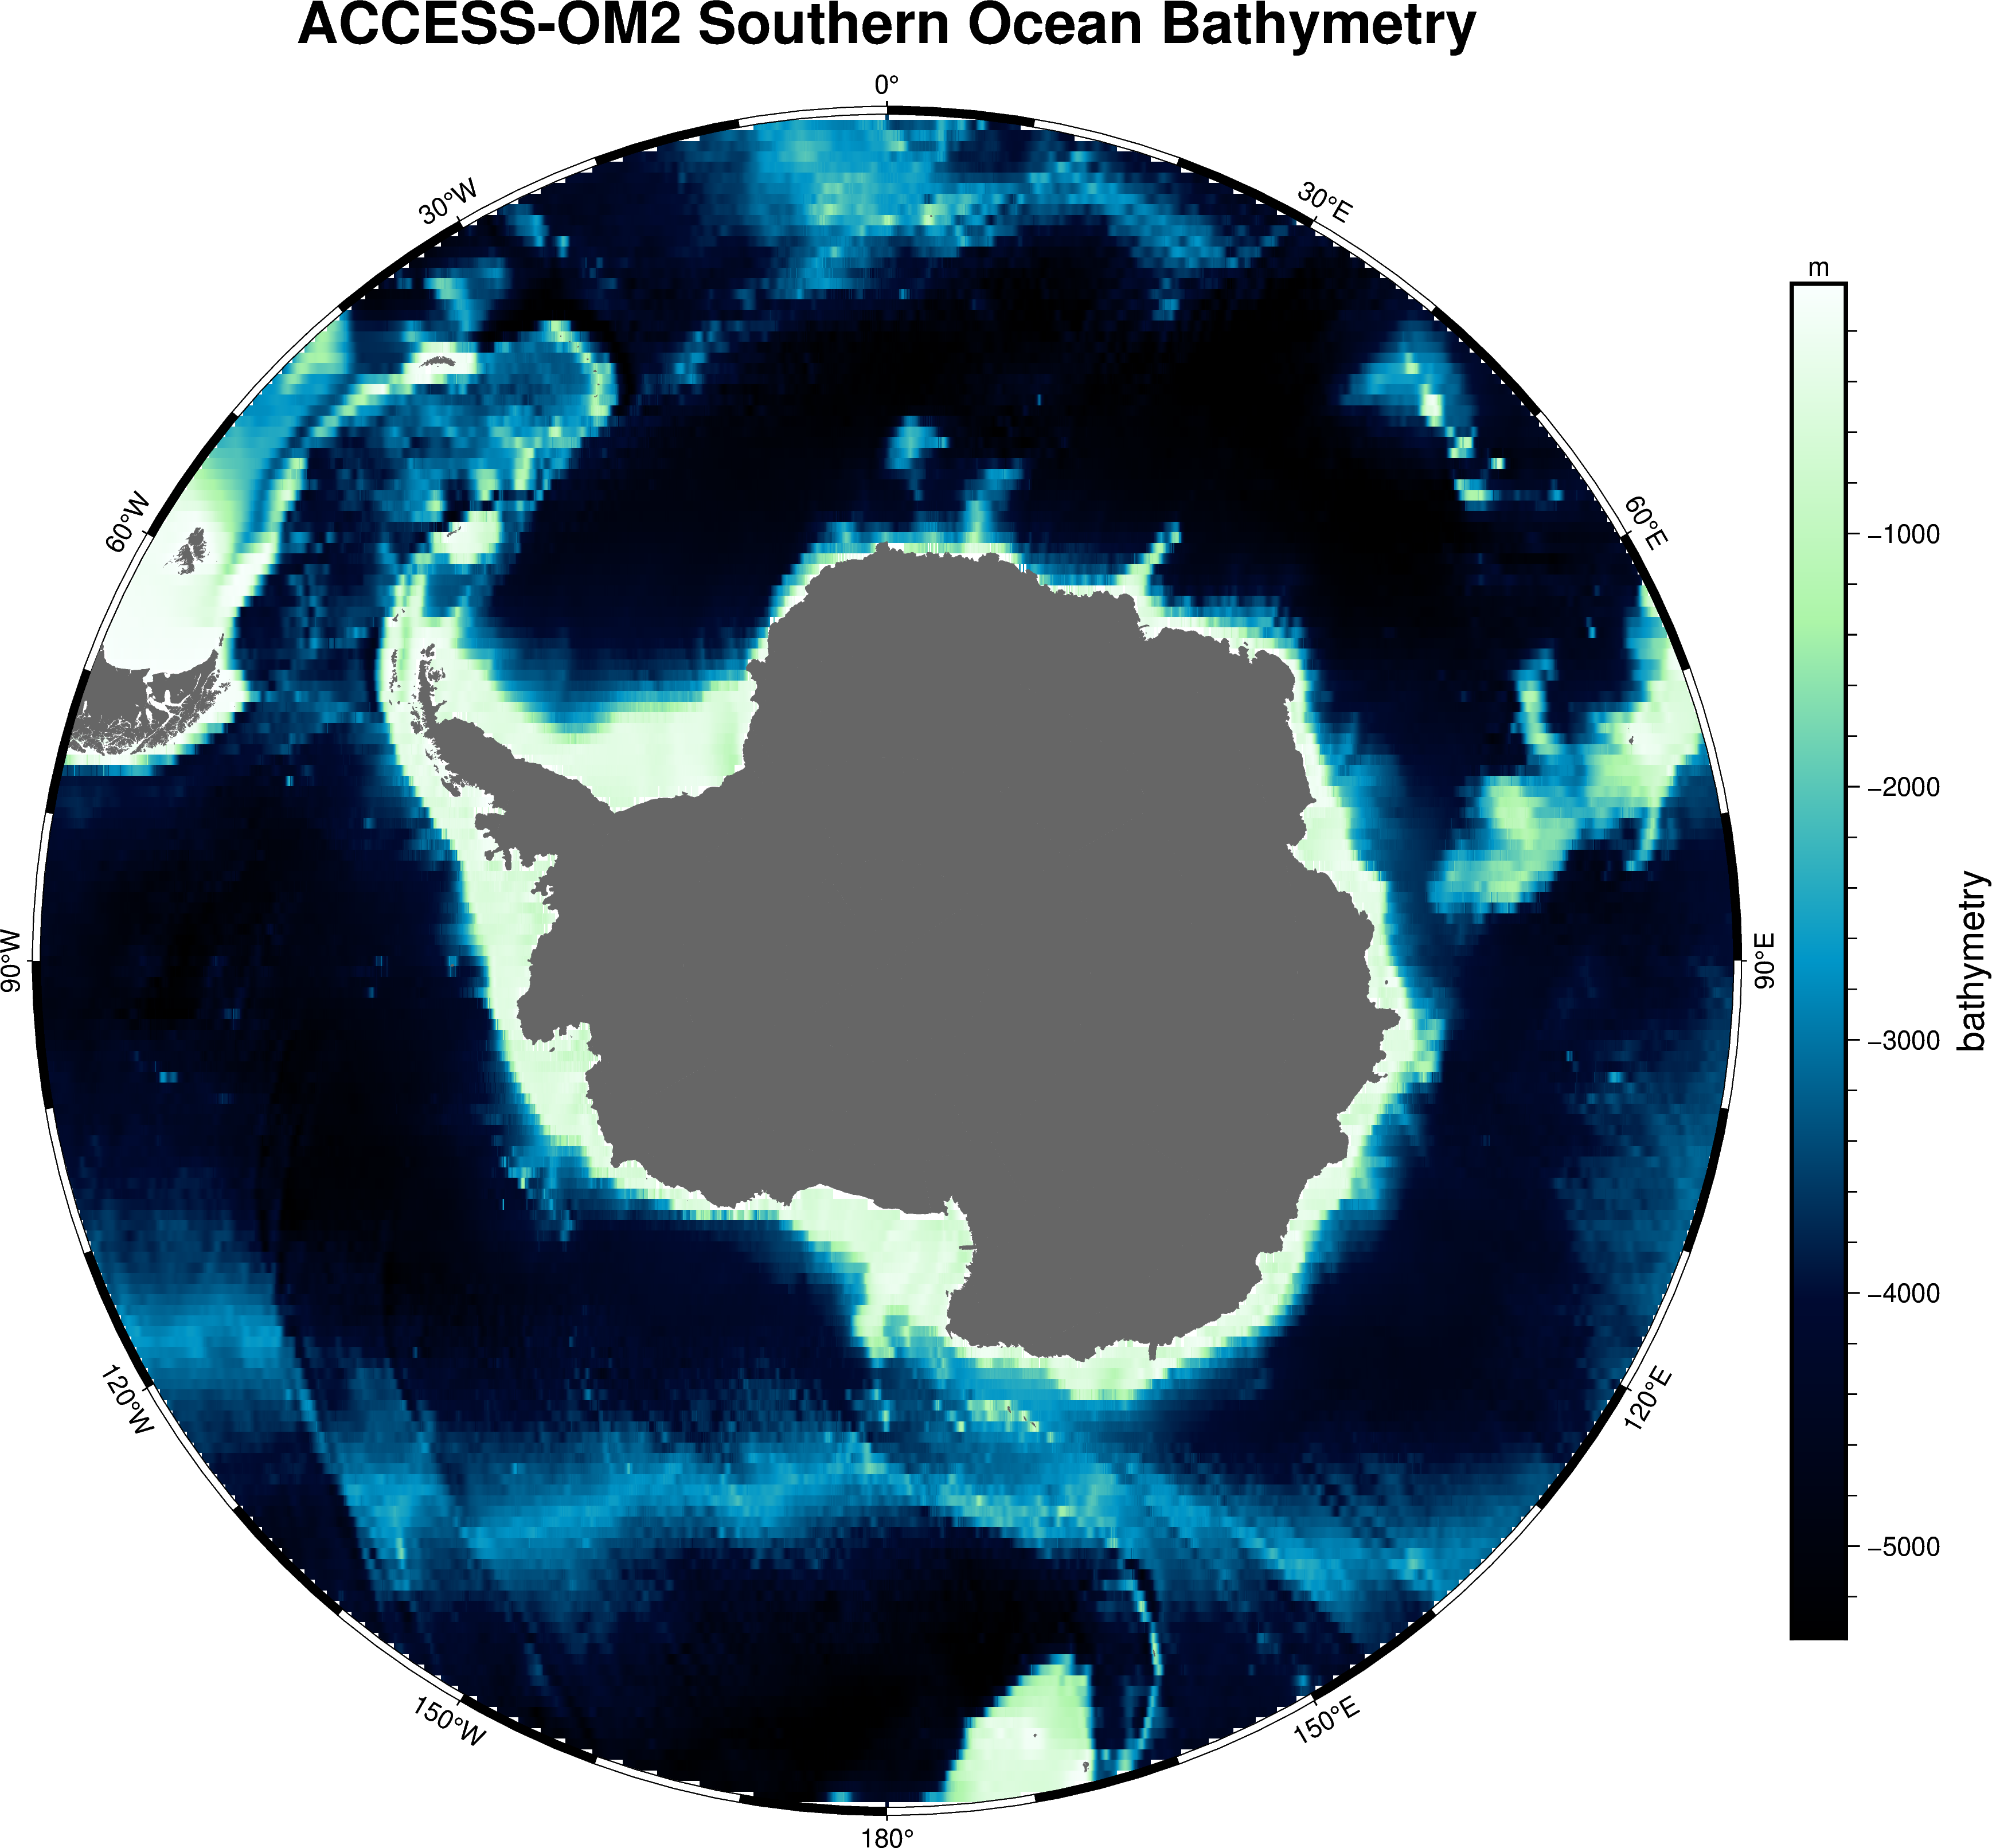

In [9]:
spacing       = '15m'
search_radius = '15m'
cmap          = 'relief'
projection    = "S0/-90/25c"
vmin          = topo.Bathymetry.min().data
vmax          = topo.Bathymetry.max().data
region        = (0,360,-90,-50)
pygmt.makecpt(cmap=cmap,series=[vmin,vmax])
g = pygmt.nearneighbor(x=np.ravel(grid.tlon.data*(180/np.pi)),
                       y=np.ravel(grid.tlat.data*(180/np.pi)),
                       z=np.ravel(topo.Bathymetry.data),
                       region=region,
                       spacing=spacing,
                       search_radius=search_radius)
fig = pygmt.Figure()
title = r"ACCESS-OM2 Southern Ocean Bathymetry"  # \047 is octal code for '
fig.basemap(region=region, projection=projection, frame=["af", f"S+t{title}"])
fig.grdimage(g,region=region, projection=projection, frame=True, cmap=cmap)
fig.coast(land="#666666")
fig.colorbar(frame=[f"x+lbathymetry", f"y+lm"], position="JRM")
fig.savefig('/g/data/jk72/da1339/GRAPHICAL/aom2_bathymetry.png')
fig.show()


Nearest lat/lon found at indices y=138, x=1316
Bathy depth before modification -372.623046875 at lon/lat 49.12500000000001/-66.50439552355827
Nearest lat/lon found at indices y=134, x=1307
Bathy depth before modification -339.7750244140625 at lon/lat 46.875/-66.92678988037794
Nearest lat/lon found at indices y=132, x=1305
Bathy depth before modification -246.73709106445312 at lon/lat 46.375/-67.13798705878777
Nearest lat/lon found at indices y=130, x=1303
Bathy depth before modification -367.3305358886719 at lon/lat 45.875/-67.3491842371976
Nearest lat/lon found at indices y=129, x=1300
Bathy depth before modification -360.4615173339844 at lon/lat 45.125/-67.45478282640252
Nearest lat/lon found at indices y=129, x=1298
Bathy depth before modification -396.5666809082031 at lon/lat 44.625/-67.45478282640252
Nearest lat/lon found at indices y=128, x=1297
Bathy depth before modification -351.3264465332031 at lon/lat 44.375/-67.56038141560745
Nearest lat/lon found at indices y=127, x=1295
B

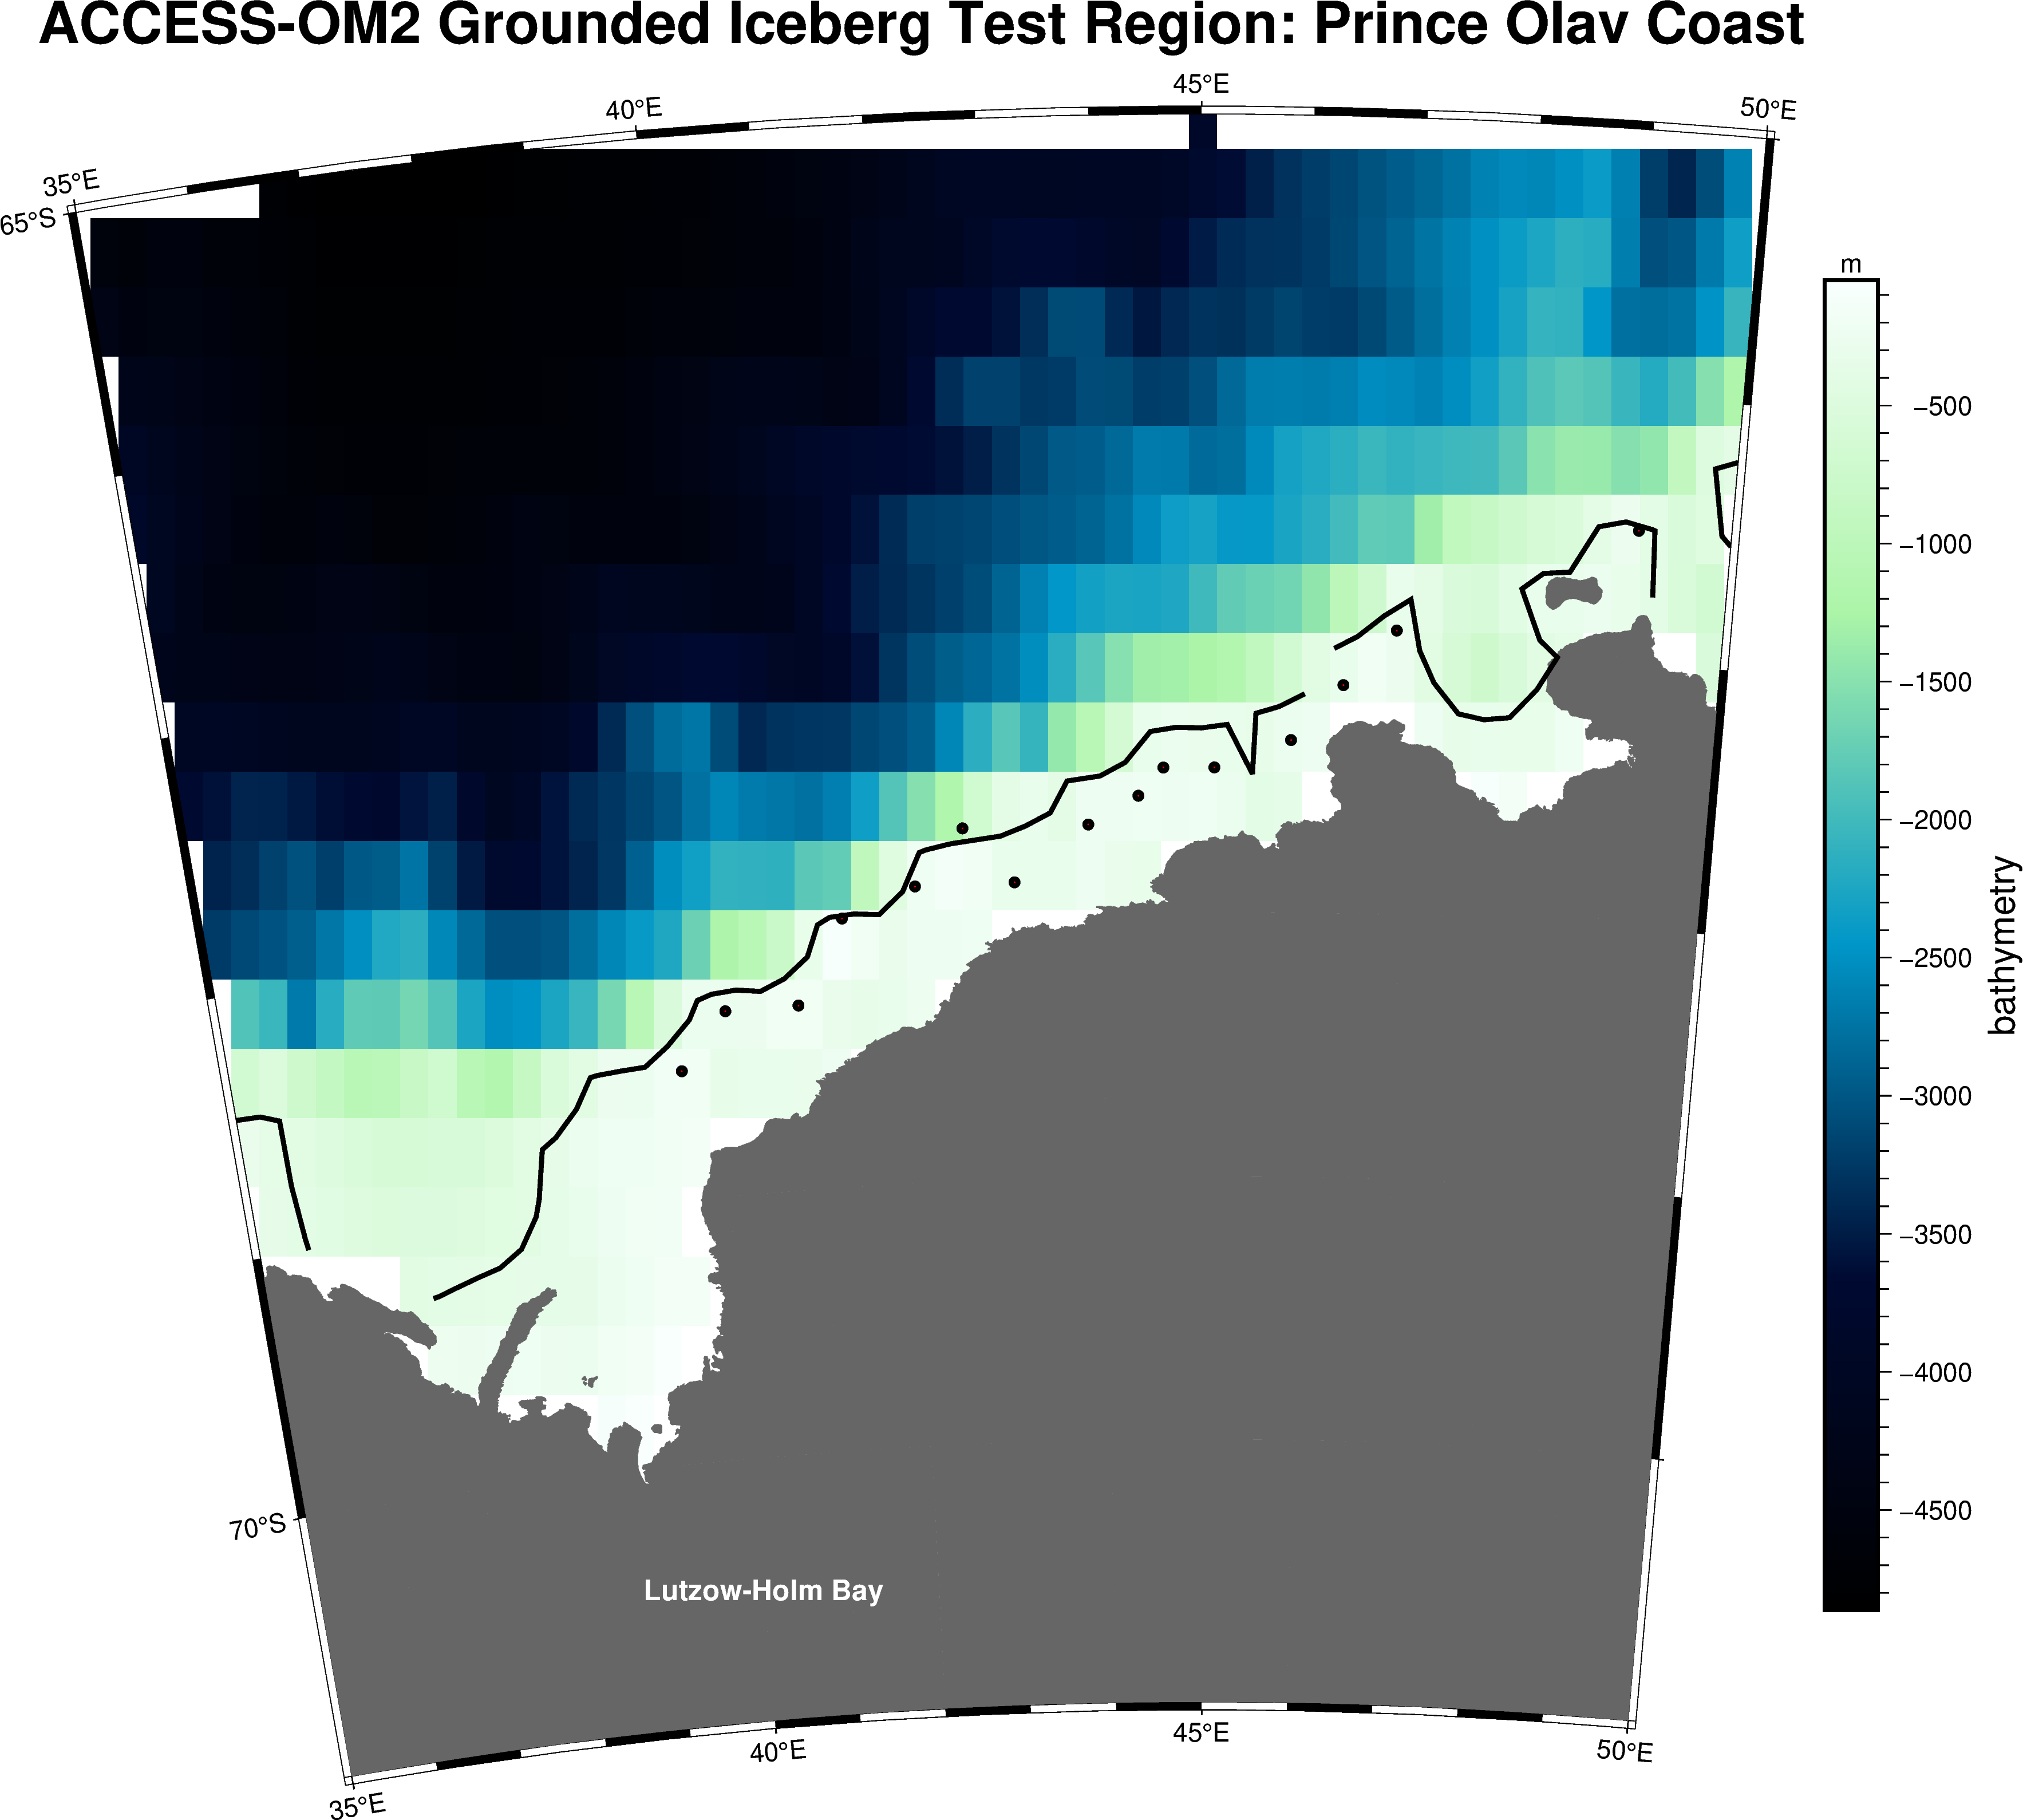

In [142]:
tlon_deg = np.degrees(grid['tlon'].values)
tlat_deg = np.degrees(grid['tlat'].values)
lon_srch = [ 49.1, 46.9, 46.3, 45.9, 45.1, 44.7, 44.3, 43.9, 43.1, 42.7, 42.1, 41.5, 41.0, 40.2, 39.7]
lat_srch = [-66.5,-66.9,-67.1,-67.3,-67.5,-67.5,-67.6,-67.7,-67.9,-67.7,-67.9,-68.0,-68.3,-68.3,-68.5]
lon_fnd  = []
lat_fnd  = []
for i in range(len(lon_srch)):   
    lat_diff = (tlat_deg - lat_srch[i])**2
    lon_diff = (tlon_deg - lon_srch[i])**2
    total_diff = lat_diff + lon_diff
    yi, xi = np.unravel_index(total_diff.argmin(), total_diff.shape)
    print(f"Nearest lat/lon found at indices y={yi}, x={xi}")
    print(f'Bathy depth before modification {topo.Bathymetry[yi,xi].data} at lon/lat {tlon_deg[yi,xi]}/{tlat_deg[yi,xi]}')
    lon_fnd.append(tlon_deg[yi,xi])
    lat_fnd.append(tlat_deg[yi,xi])
    topo.Bathymetry[yi,xi] = -.2
spacing       = '15m'
search_radius = '15m'
projection    = "S45/-90/25c"
region        = (35,50,-71,-65)
fig           = pygmt.Figure()
title         = r"ACCESS-OM2 Grounded Iceberg Test Region: Prince Olav Coast"
g = pygmt.nearneighbor(x=np.ravel(grid.tlon.data*(180/np.pi)),
                       y=np.ravel(grid.tlat.data*(180/np.pi)),
                       z=np.ravel(topo.Bathymetry.data),
                       region=region,
                       spacing=spacing,
                       search_radius=search_radius)
pygmt.makecpt(cmap=cmap, series=[-500,0])
pygmt.makecpt(cmap=cmap, series=[vmin,-500], background='darkblue')
fig.basemap(region=region, projection=projection, frame=["af", f"S+t{title}"])
fig.grdimage(g,region=region, projection=projection, frame=True, cmap=cmap)
fig.coast(land="#666666")
fig.colorbar(frame=[f"x+lbathymetry", f"y+lm"], position="JRM")
fig.grdcontour(grid=g,interval=20,limit=[-410,-390],pen='2p')
for i in range(len(lon_fnd)):
    fig.plot(x=lon_fnd[i], y=lat_fnd[i], style="c.1c", fill="red", pen="2p")
fig.text(x=40, y=-70.5, text="Lutzow-Holm Bay", font="12p,Helvetica-Bold,white")
fig.savefig('/g/data/jk72/da1339/GRAPHICAL/aom2_bathymetry_prince_olav_coast.png')
fig.show()

In [143]:
topo['Bathymetry'] = topo.Bathymetry*(-1)
print(topo.Bathymetry.min().data)
print(topo.Bathymetry.max().data)

0.20000000298023224
5363.46923828125


In [144]:
topo.to_netcdf('/scratch/jk72/da1339/cice-dirs/input/AFIM/grid/0p25/topog_renamed_neg0p2m_mods.nc')